# Record Audio From Microphone

In [1]:
import sounddevice as sd

duration = 5  # seconds
sampling_rate = 16000  # Hz

recording = sd.rec(duration * sampling_rate, samplerate=sampling_rate, channels=1)
print("Recording...")
sd.wait()  # Wait until the recording is finished
print("Recording finished.")

Recording...
Recording finished.


In [ ]:
print("audio data shape:", recording.shape)
print(recording[-10:])  # Print the last 10 samples of the recording

audio data shape: (80000, 1)
[[-0.00091553]
 [ 0.00259399]
 [ 0.00357056]
 [ 0.00387573]
 [ 0.00491333]
 [ 0.0050354 ]
 [-0.00231934]
 [-0.00436401]
 [ 0.00436401]
 [-0.00375366]]


In [16]:
from IPython.display import Audio

Audio(recording.flatten(), rate=sampling_rate)

# Visualize Waveform and Spectrogram

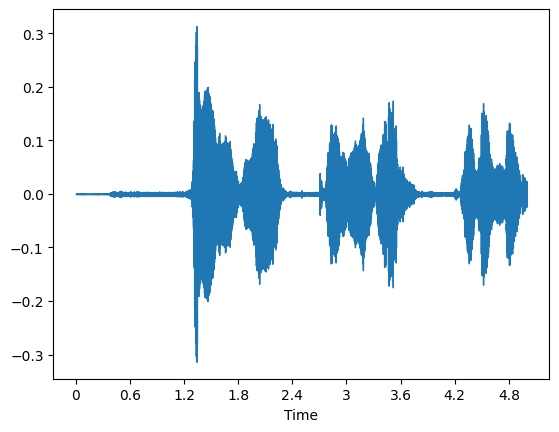

In [10]:
import librosa
import matplotlib.pyplot as plt

librosa.display.waveshow(recording.flatten(), sr=sampling_rate)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_30992\449675673.py:3: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  D = librosa.amplitude_to_db(librosa.stft(recording.flatten()), ref=np.max)


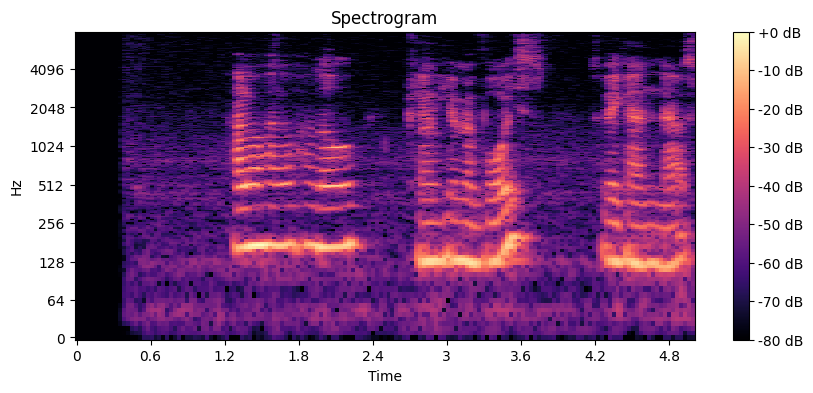

In [12]:
import numpy as np

D = librosa.amplitude_to_db(librosa.stft(recording.flatten()), ref=np.max)
plt.figure(figsize=(10, 4))
librosa.display.specshow(D, sr=sampling_rate, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.show()

# Load and Write Audio File

In [13]:
import soundfile as sf

sf.write("recoding.wav", recording, sampling_rate)

In [15]:
recording, sampling_rate = sf.read("recoding.wav")
print(recording.shape, sampling_rate)

(80000,) 16000


# Resample

In [26]:
resampled_rate = 4000
resampled_recording = librosa.resample(
    recording.flatten(), orig_sr=sampling_rate, target_sr=resampled_rate
)
print(resampled_recording.shape)

(20000,)
